In [ ]:
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Install dependencies

In [ ]:
!pip install -q --no-deps trl peft accelerate bitsandbytes

In [ ]:
!pip install -q datasets matplotlib

In [ ]:
!pip install psutil

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

In [ ]:
import torch

In [ ]:
if torch.cuda.is_available():
    print(f"CUDA is available! Number of GPUs: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
    print(f"Current CUDA device: {torch.cuda.current_device()}")
else:
    print("CUDA is not available on this system.")

CUDA is available! Number of GPUs: 1
  GPU 0: NVIDIA RTX PRO 6000 Blackwell Server Edition
Current CUDA device: 0


## Check Hardware

In [ ]:
import psutil
import torch


In [ ]:
# System RAM
sys_ram = psutil.virtual_memory().total / (1024**3) # Convert bytes to GB
print(f"System RAM: {sys_ram:.2f} GB")

# CPU Cores
cpu_cores = psutil.cpu_count(logical=False) # Physical cores
print(f"CPU Physical Cores: {cpu_cores}")
cpu_logical_cores = psutil.cpu_count(logical=True) # Logical cores (includes hyperthreading)
print(f"CPU Logical Cores: {cpu_logical_cores}")

# GPU RAM (from torch)
if torch.cuda.is_available():
    gpu_ram_bytes = torch.cuda.get_device_properties(0).total_memory
    gpu_ram_gb = gpu_ram_bytes / (1024**3) # Convert bytes to GB
    print(f"GPU RAM: {gpu_ram_gb:.2f} GB")
else:
    print("CUDA is not available, cannot retrieve GPU RAM.")

System RAM: 176.88 GB
CPU Physical Cores: 24
CPU Logical Cores: 48
GPU RAM: 94.97 GB


In [ ]:
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}")
    print(f"VRAM: {props.total_memory / 1e9:.1f} GB")
print(f"bf16 supported: {is_bfloat16_supported()}")

CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 102.0 GB
bf16 supported: True


## Set Smoke test : True:  
It Run a tiny SMOKE_TEST (few steps) to confirm the model loads and loss goes down.

In [ ]:
SMOKE_TEST = False
RESUME = True

In [ ]:
MODEL_NAME = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit"
MAX_SEQ_LENGTH = 4096
LOAD_IN_4BIT = True

### LoRA

In [ ]:
LORA_R = 64
LORA_ALPHA = 64
LORA_DROPOUT = 0.0
TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
]

### Path to Master dataset in MyDrive

In [ ]:
DRIVE_ROOT = "/content/drive/MyDrive/Aegis-CyberSec-Guard"
DATA_DIR = os.path.join(DRIVE_ROOT, "dataV5")
TRAIN_PATH = os.path.join(DATA_DIR, "master_train.jsonl")
VAL_PATH = os.path.join(DATA_DIR, "master_val.jsonl")
HOLDOUT_PATH = os.path.join(DATA_DIR, "holdout_300.jsonl")

In [ ]:
OUTPUT_DIR = os.path.join(DRIVE_ROOT, "checkpoints")
LOGGING_DIR = os.path.join(DRIVE_ROOT, "logs")
FINAL_ADAPTER_DIR = os.path.join(DRIVE_ROOT, "final_adapter")

### Training HyperParameters

In [ ]:
PER_DEVICE_TRAIN_BATCH_SIZE = 12
GRADIENT_ACCUMULATION_STEPS = 2
NUM_TRAIN_EPOCHS = 3
LEARNING_RATE = 2e-4
WARMUP_RATIO = 0.03
LR_SCHEDULER_TYPE = "cosine"
WEIGHT_DECAY = 0.01

In [ ]:
SAVE_STEPS = 50
SAVE_TOTAL_LIMIT = 3
LOGGING_STEPS = 5
EVAL_STEPS = 50
SEED = 3407

### Unsloth must be imported before transformers so its patches apply.

In [ ]:
SMOKE_MAX_STEPS = 20
SMOKE_SUBSET = 200

In [ ]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOGGING_DIR, exist_ok=True)

In [ ]:
print(f"SMOKE_TEST = {SMOKE_TEST}")
print(f"RESUME     = {RESUME}")
print(f"Reading train from: {TRAIN_PATH}")

SMOKE_TEST = False
RESUME     = True
Reading train from: /content/drive/MyDrive/Aegis-CyberSec-Guard/dataV5/master_train.jsonl


In [ ]:
import json
import random

In [ ]:
import torch
from unsloth import FastLanguageModel, is_bfloat16_supported
from unsloth.chat_templates import train_on_responses_only
from datasets import load_dataset
from trl import SFTTrainer, SFTConfig

In [ ]:
random.seed(SEED)
torch.manual_seed(SEED)

### The JSONL   has the {"messages": [...], "source", "task"} schema from the ETL.

##  Load Model and Tokenizer
The tokenizer is Qwen2.5 whose onw BPE tokenizer
A Model only understand its own token IDs.

In [ ]:
train_ds = load_dataset("json", data_files=TRAIN_PATH, split="train")
val_ds = load_dataset("json", data_files=VAL_PATH, split="train")

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
print(f"train: {len(train_ds)} rows")
print(f"val:   {len(val_ds)} rows")
print(f"columns: {train_ds.column_names}")

train: 55275 rows
val:   2926 rows
columns: ['messages', 'source', 'task']


In [ ]:
if SMOKE_TEST:
    train_ds = train_ds.select(range(min(SMOKE_SUBSET, len(train_ds))))
    val_ds = val_ds.select(range(min(50, len(val_ds))))
    print(f"\nSMOKE_TEST active -> train: {len(train_ds)}, val: {len(val_ds)}")


In [ ]:
bad = []
for i, ex in enumerate(train_ds):
    for j, msg in enumerate(ex["messages"]):
        c = msg.get("content")
        if not isinstance(c, str):
            bad.append((i, j, type(c).__name__, c))
        elif c.strip() == "":
            bad.append((i, j, "empty_string", c))

print(f"bad rows: {len(bad)}")
for b in bad[:10]:
    print(b)

bad rows: 0


In [ ]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=LOAD_IN_4BIT,
    dtype=None,  # auto-detect bf16/fp16
)

==((====))==  Unsloth 2026.7.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=TARGET_MODULES,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
)

Unsloth 2026.7.2 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


In [ ]:
model.print_trainable_parameters()

trainable params: 161,480,704 || all params: 7,777,097,216 || trainable%: 2.0764


## Token-Length Sanity Check
Characters are not otkens it must be checked below  in roder to ensore a smooth traiining avoid messing up my training runs

In [ ]:
def rendered_token_len(example):
    text = tokenizer.apply_chat_template(
        example["messages"], tokenize=False, add_generation_prompt=False
    )
    return len(tokenizer(text)["input_ids"])



In [ ]:
sample_n = min(1000, len(train_ds))
lengths = [rendered_token_len(train_ds[i]) for i in range(sample_n)]
lengths.sort()
over = sum(1 for l in lengths if l > MAX_SEQ_LENGTH)

In [ ]:
print(f"Sampled {sample_n} rows")
print(f"  p50: {lengths[len(lengths)//2]} tokens")
print(f"  p95: {lengths[int(len(lengths)*0.95)]} tokens")
print(f"  max: {lengths[-1]} tokens")
print(f"  over {MAX_SEQ_LENGTH}: {over} ({100*over/sample_n:.1f}%) -> these get truncated")

Sampled 1000 rows
  p50: 506 tokens
  p95: 1151 tokens
  max: 3058 tokens
  over 4096: 0 (0.0%) -> these get truncated


Formatting Function  [ disabled after first run ]

In [ ]:
def formatting_func(example):
    return [tokenizer.apply_chat_template(
        example["messages"], tokenize=False, add_generation_prompt=False
    )]

## Training Configuration
Max_Steps is set only for the smoke trst,  later on It will use num_train_epochs o nreal run .

In [ ]:
effective_epochs = 1 if SMOKE_TEST else NUM_TRAIN_EPOCHS
effective_max_steps = SMOKE_MAX_STEPS if SMOKE_TEST else -1


In [ ]:
# Pre-renderiza a una columna 'text'
def add_text(example):
    example["text"] = tokenizer.apply_chat_template(
        example["messages"], tokenize=False, add_generation_prompt=False
    )
    return example

train_ds = train_ds.map(add_text)
val_ds = val_ds.map(add_text)

# Verifica que 'text' es string no vacio
print(type(train_ds[0]["text"]), len(train_ds[0]["text"]))

Map:   0%|          | 0/55275 [00:00<?, ? examples/s]

Map:   0%|          | 0/2926 [00:00<?, ? examples/s]

<class 'str'> 2638


Master Configuration

In [ ]:

sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    num_train_epochs=effective_epochs,
    max_steps=effective_max_steps,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type=LR_SCHEDULER_TYPE,
    weight_decay=WEIGHT_DECAY,
    logging_dir=LOGGING_DIR,
    logging_steps=LOGGING_STEPS,
    save_steps=SAVE_STEPS,
    save_total_limit=SAVE_TOTAL_LIMIT,
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    load_best_model_at_end=(not SMOKE_TEST),   # keep the best-val checkpoint, not the last
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    bf16=is_bfloat16_supported(),
    fp16=not is_bfloat16_supported(),
    optim="adamw_8bit",
    seed=SEED,
    report_to="none",
    max_seq_length=MAX_SEQ_LENGTH,
    packing=False,
    dataset_text_field="text",
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer Setup

In [ ]:
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    args=sft_config,

)

Unsloth: Tokenizing ["text"] (num_proc=52):   0%|          | 0/55275 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=52):   0%|          | 0/2926 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


VRAM Baseline before training.

In [ ]:
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    props = torch.cuda.get_device_properties(0)
    reserved = torch.cuda.max_memory_reserved() / 1e9
    print(f"GPU: {props.name}")
    print(f"Reserved before training: {reserved:.2f} GB / {props.total_memory / 1e9:.1f} GB")


GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Reserved before training: 6.33 GB / 102.0 GB


### Checkpoint Discovery for Real Run

In [ ]:

def find_last_checkpoint(output_dir):

    if not os.path.isdir(output_dir):

        return None

    cks = [d for d in os.listdir(output_dir)

           if d.startswith("checkpoint-") and os.path.isdir(os.path.join(output_dir, d))]

    if not cks:

        return None

    cks.sort(key=lambda d: int(d.split("-")[-1]))

    return os.path.join(output_dir, cks[-1])


In [ ]:
resume_path = find_last_checkpoint(OUTPUT_DIR) if (RESUME and not SMOKE_TEST) else None
if resume_path:
    print(f"Resuming from: {resume_path}")
else:
    print("Starting fresh.")


Resuming from: /content/drive/MyDrive/Aegis-CyberSec-Guard/checkpoints/checkpoint-150


## Train LLM

SMOKE_TEST: a few steps to confirm the model loads and loss decreases. Cheap.


 Real run: full training

In [ ]:
trainer_stats = trainer.train(resume_from_checkpoint=resume_path)


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 55,275 | Num Epochs = 3 | Total steps = 6,912
O^O/ \_/ \    Batch size per device = 12 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (12 x 2 x 1) = 24
 "-____-"     Trainable parameters = 161,480,704 of 7,777,097,216 (2.08% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
200,1.058180,1.020077
250,0.987876,0.992787
300,0.959798,0.970407
350,0.974118,0.954969
400,0.958650,0.940252
450,0.968929,0.930109
500,0.880029,0.920330
550,0.948989,0.913324
600,0.939610,0.902093
650,0.959873,0.895581


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Aegis-CyberSec-Guard/checkpoints/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Aegis-CyberSec-Guard/checkpoints/checkpoint-250/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Aegis-CyberSec-Guard/checkpoints/checkpoint-300/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Aegis-CyberSec-Guard/checkpoints/checkpoint-350/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Aegis-CyberSec-Guard/checkpoints/checkpoint-400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Aegis-CyberSec-Guard/checkpoints/checkpoint-450/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Aegis-CyberSec-Guard/checkpoints/checkpoint-500/tokenize

Step,Training Loss,Validation Loss
200,1.058180,1.020077
250,0.987876,0.992787
300,0.959798,0.970407
350,0.974118,0.954969
400,0.958650,0.940252
450,0.968929,0.930109
500,0.880029,0.920330
550,0.948989,0.913324
600,0.939610,0.902093
650,0.959873,0.895581


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Aegis-CyberSec-Guard/checkpoints/checkpoint-950/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Aegis-CyberSec-Guard/checkpoints/checkpoint-1000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Aegis-CyberSec-Guard/checkpoints/checkpoint-1050/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Aegis-CyberSec-Guard/checkpoints/checkpoint-1100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Aegis-CyberSec-Guard/checkpoints/checkpoint-1150/tokenizer_config.json.


KeyboardInterrupt: 

Training was Interrupted  after seven bleeding hours,  I found out my bad was to savbe checkpints evry fifty steps , it made my training longer than expected,
I save checkpoint af checkpint 1150 , Vl_loss = 0.845

 Post-training memory and time report

In [ ]:

if torch.cuda.is_available():
    peak = torch.cuda.max_memory_reserved() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"Peak reserved VRAM: {peak:.2f} GB / {total:.1f} GB")
    print(f"Headroom: {total - peak:.2f} GB  <- if large, raise batch size for the real run")

Peak reserved VRAM: 100.86 GB / 102.0 GB
Headroom: 1.11 GB  <- if large, raise batch size for the real run


In [ ]:

runtime_s = trainer_stats.metrics["train_runtime"]
print(f"Runtime: {runtime_s:.0f} s ({runtime_s/60:.1f} min)")
print(f"Estimated credits at 9/hour: {(runtime_s/3600)*9:.2f}")


Paased out smoke test

In [ ]:
if SMOKE_TEST:
    print("\nSMOKE TEST DONE. If loss went down and no errors:")
    print("  1. Set SMOKE_TEST = False in Cell 3")
    print("  2. Re-run Cells 3, 5, 6, 9, 10, 11, 12")
    print("  3. Run Cell 13 for the real training")

In [ ]:
import matplotlib.pyplot as plt

history = trainer.state.log_history

##  Plot training and validation curves

In [ ]:
train_steps, train_loss = [], []
eval_steps, eval_loss = [], []


### Reads the loss history the trainer logged. Train loss should fall smoothly;

In [ ]:
for entry in history:
    if "loss" in entry and "step" in entry:
        train_steps.append(entry["step"])
        train_loss.append(entry["loss"])
    if "eval_loss" in entry and "step" in entry:
        eval_steps.append(entry["step"])
        eval_loss.append(entry["eval_loss"])

Training Curve and Val Curves were good enogh even touhh i  ended up interrupting the training,  I wil lresume later on next week with optimiation,  hoping Val_loss : 0.75 .

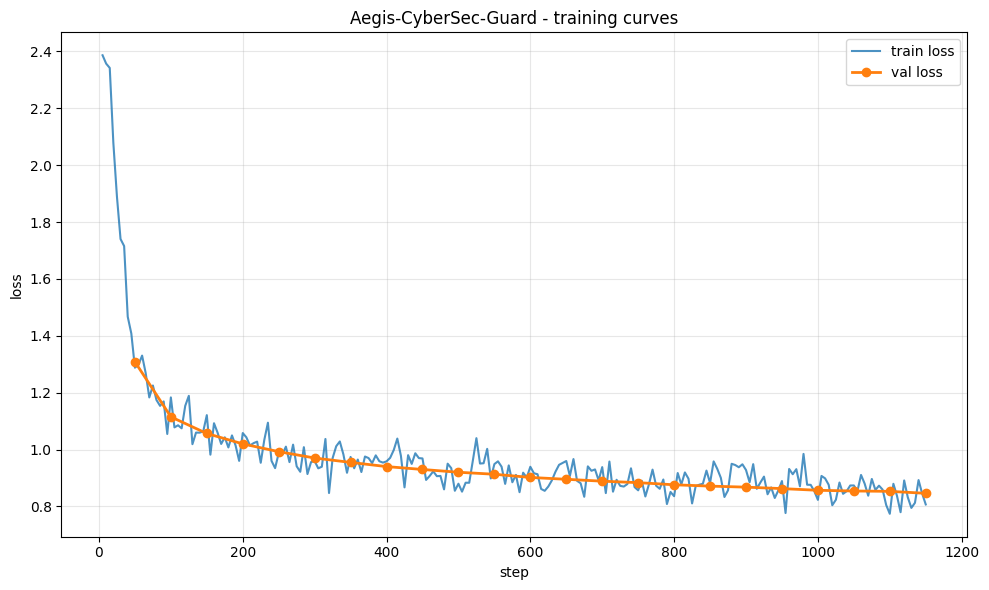

Saved: /content/drive/MyDrive/Aegis-CyberSec-Guard/logs/training_curves.png


In [ ]:

plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label="train loss", alpha=0.8)
if eval_loss:
    plt.plot(eval_steps, eval_loss, label="val loss", marker="o", linewidth=2)
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Aegis-CyberSec-Guard - training curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plot_path = os.path.join(LOGGING_DIR, "training_curves.png")
plt.savefig(plot_path, dpi=120)
plt.show()
print(f"Saved: {plot_path}")


In [ ]:
## Save the final adapter

In [ ]:
if not SMOKE_TEST:
    model.save_pretrained(FINAL_ADAPTER_DIR)
    tokenizer.save_pretrained(FINAL_ADAPTER_DIR)
    print(f"Final adapter saved to: {FINAL_ADAPTER_DIR}")
else:
    print("Smoke test: not saving adapter. Set SMOKE_TEST=False for the real run.")

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Aegis-CyberSec-Guard/final_adapter/tokenizer_config.json.


Final adapter saved to: /content/drive/MyDrive/Aegis-CyberSec-Guard/final_adapter


## Inference Smoke test by the current fine-tuned model

In [ ]:
#A qualitative check: does the model reason like a blue-team analyst?


In [ ]:

if not SMOKE_TEST:
    FastLanguageModel.for_inference(model)

    messages = [
        {
            "role": "system",
            "content": (
                "You are Aegis-CyberSec-Guard, a blue-team cybersecurity analyst assistant. "
                "You analyze logs, network events, and vulnerability data to detect threats "
                "and recommend defensive remediation. You never generate exploit code, "
                "malware, or offensive attack tooling."
            ),
        },
        {
            "role": "user",
            "content": (
                "A host made 400 outbound DNS queries in 60 seconds, each with a long "
                "randomized subdomain, all to the same nameserver. What is happening and "
                "what should we do?"
            ),
        },
    ]

    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")

    out = model.generate(input_ids=inputs, max_new_tokens=400, temperature=0.3, do_sample=True)
    print(tokenizer.decode(out[0], skip_special_tokens=True))


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=400) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_

system
You are Aegis-CyberSec-Guard, a blue-team cybersecurity analyst assistant. You analyze logs, network events, and vulnerability data to detect threats and recommend defensive remediation. You never generate exploit code, malware, or offensive attack tooling.
user
A host made 400 outbound DNS queries in 60 seconds, each with a long randomized subdomain, all to the same nameserver. What is happening and what should we do?
assistant
This behavior strongly suggests a distributed denial-of-service (DDoS) attack specifically targetingting DNS infrastructure. The attacker is likely using multiple compromised hosts to flood the target nameserver with high-volume DNS requests, potentially overwhelming its capacity or causing resource exhaustion.

**Technical Analysis:**
The pattern matches common DDoS signatures where attackers generate volumetric traffic through:
- High-frequency DNS queries (400/minute threshold indicates abnormal activity)
- Randomized subdomains to evade signature-bas

Desicions to take, fix attention mask and ack token lenghts

In [ ]:
# pending fine -tuning v2